# 08 — AQR-style factor strategies

## tl;dr

AQR publicly describes systematic value, momentum, quality, and defensive styles. This notebook tests simple, liquid ETF proxies for those styles and an equal-weight multi-style blend. It is an educational proxy experiment, not a replication of AQR's proprietary stock-level process.

> Educational research only. This notebook is not investment advice.

## Context & methods

A factor is a measurable characteristic used to form a portfolio. Value favors relatively inexpensive assets, momentum favors recent winners, quality favors profitable or financially sound companies, and defensive strategies favor lower-risk exposures. AQR's public material describes these styles as systematic building blocks.

### Key assumptions

- `VTV` is a value proxy, `MTUM` a momentum proxy, `QUAL` a quality proxy, and `USMV` a defensive/low-volatility proxy.
- The multi-style portfolio holds the four proxies equally and rebalances only through the ETFs' own internal rules; external portfolio turnover is therefore understated.
- Adjusted Yahoo Finance closes are used from the common ETF history. Signals are executed with the existing one-bar delay, and 10 bps is charged when the research portfolio changes exposure.
- The last 20% of the history is an untouched formal test period.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import run_backtest, split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import comparison_table, metrics_for_period

## Data

The common sample begins in 2013 because the factor ETFs have different launch dates. Using the common intersection avoids silently treating missing prices as zero returns.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['VTV', 'MTUM', 'QUAL', 'USMV', 'SPY']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=3_000, seed=i + 10, start='2013-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2013-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=3_000, seed=i + 10, start='2013-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

Data: 2013-07-18 through 2025-12-31 (3,134 common trading days)
{'train': (datetime.date(2013, 7, 18), datetime.date(2021, 1, 4), 1880), 'validation': (datetime.date(2021, 1, 5), datetime.date(2023, 7, 3), 627), 'test': (datetime.date(2023, 7, 5), datetime.date(2025, 12, 31), 627)}


## Public research and strategy translation

- [AQR: Understanding Factor Investing](https://funds.aqr.com/Insights/Strategies/Understanding-Factor-Investing) describes value, momentum, quality, and defensive styles.
- [AQR: Investing with Style](https://www.aqr.com/insights/research/journal-article/investing-with-style) explains combining styles across liquid markets.
- [AQR: Understanding Defensive Equity](https://www.aqr.com/Insights/Research/White-Papers/Understanding-Defensive-Equity) motivates the low-risk proxy.

The translation is intentionally conservative: it tests public ETF exposures rather than claiming to know AQR's security rankings, data, optimization, leverage, shorting, or execution.

In [3]:
factor_labels = {
    'AQR value proxy': 'VTV',
    'AQR momentum proxy': 'MTUM',
    'AQR quality proxy': 'QUAL',
    'AQR defensive proxy': 'USMV',
}
results = {}
for name, ticker in factor_labels.items():
    results[name] = run_backtest(
        close[ticker], pd.Series(1.0, index=close.index),
        transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns,
    )

blend_weights = pd.DataFrame(0.0, index=close.index, columns=close.columns)
blend_weights[['VTV', 'MTUM', 'QUAL', 'USMV']] = 0.25
results['AQR equal-weight multi-style'] = run_portfolio_backtest(
    close, blend_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
)

test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
AQR value proxy,15.12%,12.49%,1.19,1.75,-14.52%,1.04,53.19%,0.00,0,41.95%,0.586529,-16.70%
AQR momentum proxy,26.10%,19.76%,1.27,1.87,-20.99%,1.24,54.79%,0.00,0,78.08%,0.586529,19.43%
AQR quality proxy,18.21%,14.75%,1.21,1.80,-18.00%,1.01,54.41%,0.00,0,51.63%,0.586529,-7.03%
AQR defensive proxy,11.93%,10.56%,1.12,1.61,-9.36%,1.27,54.74%,0.00,0,32.36%,0.586529,-26.30%
AQR equal-weight multi-style,17.99%,13.20%,1.32,1.96,-15.36%,1.17,54.07%,0.00,0,50.92%,0.586529,-7.74%


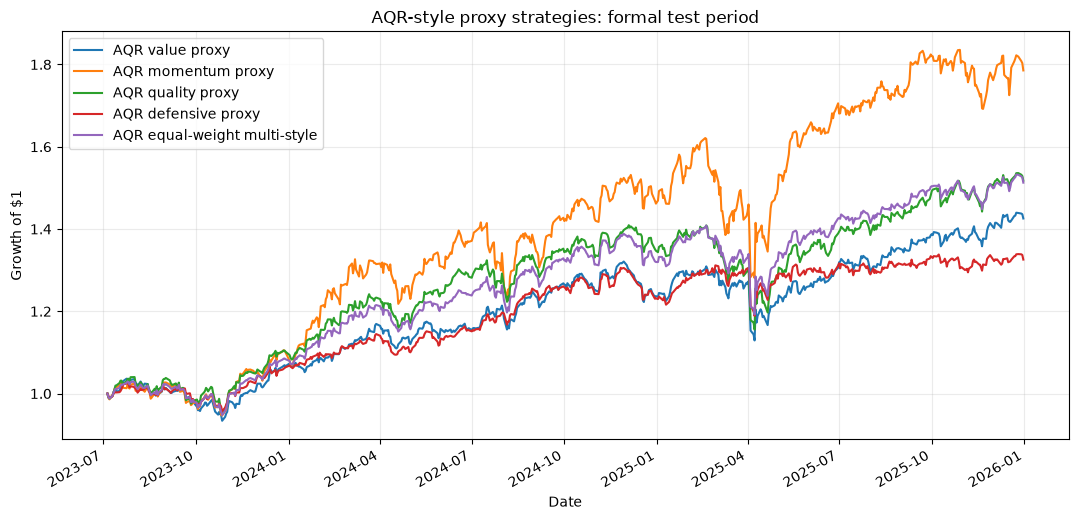

In [4]:
ax = None
for name, result in results.items():
    equity = result.frame['equity'].loc[splits['test'].index]
    ax = (equity / equity.iloc[0]).plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('AQR-style proxy strategies: formal test period')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Robustness and stress diagnostics

The following table is descriptive, not a second test set. Crisis windows were selected after the fact to understand failure modes.

In [5]:
stress_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    for name, result in results.items():
        returns = result.frame.loc[index, 'net_returns']
        equity = (1.0 + returns).cumprod()
        stress_rows.append({'window': window, 'strategy': name, 'return': equity.iloc[-1] - 1.0 if len(equity) else float('nan'), 'max_drawdown': (equity / equity.cummax() - 1.0).min() if len(equity) else float('nan')})
stress_table = pd.DataFrame(stress_rows)
stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'})

,window,strategy,return,max_drawdown
0,Global Financial Crisis,AQR value proxy,nan%,nan%
1,Global Financial Crisis,AQR momentum proxy,nan%,nan%
2,Global Financial Crisis,AQR quality proxy,nan%,nan%
3,Global Financial Crisis,AQR defensive proxy,nan%,nan%
4,Global Financial Crisis,AQR equal-weight multi-style,nan%,nan%
5,COVID shock,AQR value proxy,-36.19%,-36.39%
6,COVID shock,AQR momentum proxy,-33.93%,-34.08%
7,COVID shock,AQR quality proxy,-33.84%,-34.06%
8,COVID shock,AQR defensive proxy,-33.05%,-33.02%
9,COVID shock,AQR equal-weight multi-style,-34.24%,-34.38%


In [6]:
best_sharpe = test_table['sharpe_ratio'].idxmax()
lowest_drawdown = test_table['max_drawdown'].idxmax()
print('Finding:', best_sharpe, 'had the highest test Sharpe', round(float(test_table.loc[best_sharpe, 'sharpe_ratio']), 2))
print('Finding:', lowest_drawdown, 'had the shallowest test drawdown', round(float(test_table.loc[lowest_drawdown, 'max_drawdown']) * 100, 2), 'percent')
print('Proxy caveat: ETF construction, fees, internal turnover, and launch-date selection differ from the institutional process.')

Finding: AQR equal-weight multi-style had the highest test Sharpe 1.32
Finding: AQR defensive proxy had the shallowest test drawdown -9.36 percent
Proxy caveat: ETF construction, fees, internal turnover, and launch-date selection differ from the institutional process.


## What went well / what went wrong

**What went well:** The experiment makes AQR's public style vocabulary concrete. Momentum and defensive proxies can be compared within one framework, and the equal-weight blend tests whether diversification across styles produces a smoother path than any one factor.

**What went wrong:** ETF proxies are not stock-level factor portfolios. They contain fees, sector tilts, crowding, and implementation choices that may dominate the intended factor. Value can underperform for long stretches, momentum can reverse sharply, and defensive portfolios can lag in strong bull markets. The multi-style blend also hides internal ETF turnover and does not model AQR's breadth, shorting, leverage, or proprietary risk controls.

**Beginner takeaway:** A factor label is a hypothesis, not a guarantee. Judge the return, volatility, drawdown, turnover, and stress behavior together—and do not treat the highest single-sample Sharpe as proof of an edge.